# Tree-Based Return Predictor: A Three-Factor Framework
## Quant Research Notebook — Licentiate Thesis Series

---

### Abstract

This notebook implements a **gradient-boosted tree predictor** for medium-horizon equity returns,  
trained on three families of structured features:

1. **Momentum** — time-series autocorrelation in fractionally differentiated prices  
2. **Volatility Regime** — rolling realized variance as a nonlinear conditioning variable  
3. **Mean-Reversion Signal** — z-scored deviation from a rolling exponential mean  

The predictor is evaluated under a **walk-forward (expanding window) scheme** with explicit  
transaction cost adjustment. All design decisions are grounded in the empirical structure  
of financial time series (heavy tails, volatility clustering, non-stationarity).

---

### Mathematical Motivation

Let $\{P_t\}_{t=1}^T$ be the price process of a traded asset. Define the **fractionally  
differentiated series** $\tilde{x}_t$ via the binomial expansion of the lag operator $L$:

$$\tilde{x}_t = (1 - L)^d P_t = \sum_{k=0}^{\infty} \binom{d}{k} (-1)^k P_{t-k}, \quad d \in (0, 1)$$

The minimum fractional differencing order $d^*$ is chosen such that the ADF test rejects  
non-stationarity, while maximising the correlation $\rho(\tilde{x}_t, P_t)$ (memory preservation).  

The **target variable** is the sign-adjusted forward log-return:

$$y_t = \text{sign}\left(\log \frac{P_{t+h}}{P_t}\right) \in \{-1, +1\}$$

for a horizon $h$ (configurable, default = 5 trading days).

The **feature vector** at time $t$ is:

$$\mathbf{f}_t = \left(\underbrace{\tilde{x}_{t-1}, \tilde{x}_{t-5}, \tilde{x}_{t-21}}_{\text{momentum}},\; \underbrace{\sigma^2_{t,21}}_{\text{vol regime}},\; \underbrace{z_t}_{\text{mean-reversion}}\right)$$

where $\sigma^2_{t,21}$ is the 21-day rolling realized variance and $z_t$ is the EMA-based  
z-score defined below.

---

### Why Trees? The Non-Linearity Argument

Under the **Efficient Market Hypothesis**, log-returns $r_t$ are a martingale difference  
sequence: $\mathbb{E}[r_{t+1} \mid \mathcal{F}_t] = 0$. Linear models (ARMA) are fundamentally  
limited to exploiting second-order (covariance) structure. However, empirical evidence  
from the literature (Lo & MacKinlay 1988, Jegadeesh & Titman 1993) suggests that  
**conditional** predictability exists in regime-dependent, nonlinear interaction terms.

Gradient Boosted Decision Trees (GBDT) approximate the **Bayes-optimal classifier** over  
piecewise-constant regions of the feature space via additive tree ensembles:

$$F_M(\mathbf{f}) = \sum_{m=1}^{M} \gamma_m h_m(\mathbf{f})$$

where $h_m$ are weak learners (shallow trees) and $\gamma_m$ are step sizes chosen by  
line search. This architecture naturally captures **threshold effects** (e.g., momentum  
only works in low-volatility regimes) without explicit feature engineering.

---

## 0. Environment Setup

All dependencies are standard scientific Python. `lightgbm` is the preferred GBDT backend  
for its speed and support for monotonicity constraints — a useful regularisation tool  
when we have prior beliefs about feature directionality.

In [120]:
# ─────────────────────────────────────────────────────────────
#  Standard imports
# ─────────────────────────────────────────────────────────────
import warnings
import logging
from dataclasses import dataclass, field
from typing import List, Tuple, Dict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from scipy import stats

import yfinance as yf
import lightgbm as lgb
from sklearn.metrics import accuracy_score, roc_auc_score
from statsmodels.tsa.stattools import adfuller

warnings.filterwarnings("ignore")
logging.basicConfig(level=logging.INFO, format="%(asctime)s — %(levelname)s — %(message)s")
logger = logging.getLogger(__name__)

# Aesthetic config
plt.rcParams.update({
    "figure.dpi": 130,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.family": "serif",
    "axes.titlesize": 12,
})

SEED = 42
np.random.seed(SEED)
logger.info("Environment ready.")

2026-04-11 16:11:44,702 — INFO — Environment ready.


---
## 1. Configuration

All hyperparameters are centralised in a frozen dataclass. This makes the notebook  
**reproducible** and prevents implicit parameter drift across cells — a common source  
of silent look-ahead bias in research notebooks.

In [167]:
@dataclass
class Config:
    """
    Central experiment configuration.
    Immutable by convention — clone and modify for sensitivity analysis.
    """
    # ── Universe ──────────────────────────────────────────────
    tickers: List[str] = field(default_factory=lambda: ['AAPL'])
    #                            [
    #     "AAPL", "MSFT", "JPM", "XOM", "JNJ",
    #     "GS",   "BA",   "CAT", "PFE", "WMT"
    # ])
    start_date: str = "2010-01-01"
    end_date:   str = "2019-12-31"

    # ── Target ────────────────────────────────────────────────
    forward_horizon: int = 5          # Trading days ahead to predict

    # ── Fractional Differencing ───────────────────────────────
    ffd_d:      float = 0.5           # Differencing order d ∈ (0,1)
    ffd_thresh: float = 1e-4          # Weight truncation threshold
    ffd_window: int   = 126           # Max lag window (≈ 6 months)

    # ── Feature Windows ───────────────────────────────────────
    momentum_lags: List[int] = field(default_factory=lambda: [5])
    vol_window:    int = 21           # Realized variance lookback
    ema_span:      int = 21           # EMA span for z-score

    # ── Walk-Forward Scheme ───────────────────────────────────
    min_train_days: int = 504         # Minimum training set size (≈ 2 years)
    step_days:      int = 21          # Retrain every quarter

    # ── LightGBM ──────────────────────────────────────────────
    lgb_params: Dict = field(default_factory=lambda: {
        "objective":       "binary",
        "metric":          "binary_logloss",
        "n_estimators":    300,
        "learning_rate":   0.05,
        "max_depth":       4,         # Shallow trees → regularisation
        "num_leaves":      15,
        "min_child_samples": 30,      # Prevents splitting on noise
        "subsample":       0.8,
        "colsample_bytree": 0.8,
        "reg_lambda":      1.0,       # L2 regularisation
        "verbose":         -1,
        "random_state":    42,
    })

    # ── Transaction Costs ─────────────────────────────────────
    cost_bps: float = 0.0 #10.0           # One-way cost in basis points

    # ── Probability Threshold ─────────────────────────────────
    prob_threshold: float = 0.55     # Only trade when P(up) > threshold


cfg = Config()
logger.info(f"Universe: {len(cfg.tickers)} tickers | Horizon: {cfg.forward_horizon}d")

2026-04-11 16:17:16,374 — INFO — Universe: 1 tickers | Horizon: 5d


---
## 2. Data Acquisition

We download adjusted close prices from Yahoo Finance via `yfinance`.  
The adjustment accounts for dividends and splits, making the series  
suitable for log-return computation:

$$r_t = \log P_t^{\text{adj}} - \log P_{t-1}^{\text{adj}}$$

**Important:** We use **adjusted close** only for return computation, not for  
level-based features (where raw close is more appropriate). A subtle but common error.

In [178]:
def fetch_prices(cfg: Config) -> pd.DataFrame:
    """
    Download adjusted close prices for all tickers.

    Returns
    -------
    pd.DataFrame
        Shape (T, N): DatetimeIndex rows, ticker columns.
        Forward-filled to handle occasional exchange holidays.
    """
    logger.info("Downloading price data from Yahoo Finance...")
    raw = yf.download(
        tickers=cfg.tickers,
        start=cfg.start_date,
        end=cfg.end_date,
        auto_adjust=True,
        progress=False,
        #PROXY SETTINGS (UNCOMMENT IF BEHIND A PROXY)
        proxy="http://proxy.cnea.gob.ar:1280"
    )["Close"]

    # Forward-fill gaps (≤ 3 days) then drop remaining NaNs
    prices = raw.ffill(limit=3).dropna(how="all", axis=0)

    # Drop tickers with > 5% missing observations
    pct_missing = prices.isna().mean()
    valid = pct_missing[pct_missing < 0.05].index.tolist()
    prices = prices[valid].dropna()

    logger.info(f"Prices loaded: {prices.shape[0]} days × {prices.shape[1]} tickers")
    return prices


prices = fetch_prices(cfg)
prices.tail(3)

2026-04-11 17:23:39,846 — INFO — Downloading price data from Yahoo Finance...
2026-04-11 17:23:41,732 — INFO — Prices loaded: 2515 days × 1 tickers


Ticker,AAPL
Date,
2019-12-26,69.883934
2019-12-27,69.857399
2019-12-30,70.272018


---
## 3. Fractional Differencing (FFD)

### Theoretical Motivation

Integer differencing ($d=1$) stationarises most financial price series but destroys  
long-range memory, discarding potentially predictive autocorrelation structure.  
López de Prado (2018) proposes using the **minimum $d$** such that stationarity is  
achieved while preserving maximum correlation with the original price level.

The fractional difference operator is defined via the **binomial series**:

$$\Delta^d = (1-L)^d = \sum_{k=0}^{\infty} \pi_k L^k$$

where the weights decay according to:

$$\pi_0 = 1, \qquad \pi_k = -\pi_{k-1} \cdot \frac{d - k + 1}{k}$$

Weights are **truncated** when $|\pi_k| < \epsilon$ (default $\epsilon = 10^{-4}$), making  
the computation finite and numerically stable. This introduces a fixed-width convolution  
that can be vectorised efficiently.

### Fixed-Width Window (FFD Variant)

We use the **Fixed-width window Fractional Differencing** variant, where only the most  
recent $W$ observations contribute to $\tilde{x}_t$. This prevents excessive weight on  
very old observations and controls the stationarity-memory trade-off at a given window $W$:

$$\tilde{x}_t = \sum_{k=0}^{W-1} \pi_k P_{t-k}$$

In [ ]:
def _ffd_weights(d: float, thresh: float, max_lag: int) -> np.ndarray:
    """
    Compute truncated FFD weights π_k for order d.

    The recurrence is:
        π_0 = 1
        π_k = π_{k-1} · (k - 1 - d) / k

    Weights are collected until |π_k| < thresh or k > max_lag.

    Returns
    -------
    np.ndarray
        Array of weights [π_0, π_1, ..., π_K], shape (K+1,).
    """
    weights = [1.0]
    for k in range(1, max_lag):
        w_k = -weights[-1] * (d - k + 1) / k
        if abs(w_k) < thresh:
            break
        weights.append(w_k)
    return np.array(weights)


def fractional_diff(series: pd.Series, d: float, thresh: float, max_lag: int) -> pd.Series:
    """
    Apply Fixed-Width Window Fractional Differencing to a price series.

    Parameters
    ----------
    series : pd.Series
        Raw price series (NOT log-prices; the operator acts on levels).
    d : float
        Differencing order in (0, 1).
    thresh : float
        Weight truncation threshold.
    max_lag : int
        Maximum number of lags (window width W).

    Returns
    -------
    pd.Series
        Fractionally differenced series, with NaN for the first W-1 observations.
    """
    weights = _ffd_weights(d, thresh, max_lag)  # shape (K,)
    K = len(weights)
    vals = series.values.astype(float)
    T = len(vals)

    result = np.full(T, np.nan)
    # Vectorised dot product for each valid window
    for t in range(K - 1, T):
        result[t] = np.dot(weights, vals[t: t - K if t - K >= 0 else None: -1])

    return pd.Series(result, index=series.index, name=f"ffd_{series.name}")


def apply_ffd_panel(prices: pd.DataFrame, cfg: Config) -> pd.DataFrame:
    """
    Apply FFD to every column of a price DataFrame.

    Returns
    -------
    pd.DataFrame
        Same shape as `prices`, columns renamed to ffd_{ticker}.
    """
    ffd_dict = {}
    for ticker in prices.columns:
        ffd_dict[ticker] = fractional_diff(
            prices[ticker], cfg.ffd_d, cfg.ffd_thresh, cfg.ffd_window
        )
    return pd.DataFrame(ffd_dict)


# ── Stationarity check on a sample ticker ──
sample_ffd = fractional_diff(
    raw_prices["AAPL"], cfg.ffd_d, cfg.ffd_thresh, cfg.ffd_window
).dropna()

adf_stat, adf_p, *_ = adfuller(sample_ffd, maxlag=10, autolag="AIC")
logger.info(f"ADF on FFD(AAPL, d={cfg.ffd_d}): statistic={adf_stat:.3f}, p-value={adf_p:.4f}")
print(f"\n✓ ADF p-value = {adf_p:.4f} — ", "Stationary" if adf_p < 0.05 else "⚠ NOT stationary — increase d")

# Apply to full panel
ffd_panel = apply_ffd_panel(raw_prices, cfg)
logger.info(f"FFD panel shape: {ffd_panel.shape}")

2026-04-11 16:17:16,863 — INFO — ADF on FFD(AAPL, d=0.5): statistic=-3.280, p-value=0.0158
2026-04-11 16:17:16,876 — INFO — FFD panel shape: (2515, 1)



✓ ADF p-value = 0.0158 —  Stationary


### Visual Diagnostic: Weight Decay and FFD vs Raw Price

The left panel shows how FFD weights decay with lag — a power-law decay  
governed by $d$, contrasted with integer differencing ($d=1$, only $\pi_0 = 1$).  
The right panel overlays the FFD series against the raw price to confirm that  
memory (co-movement with level) is preserved.

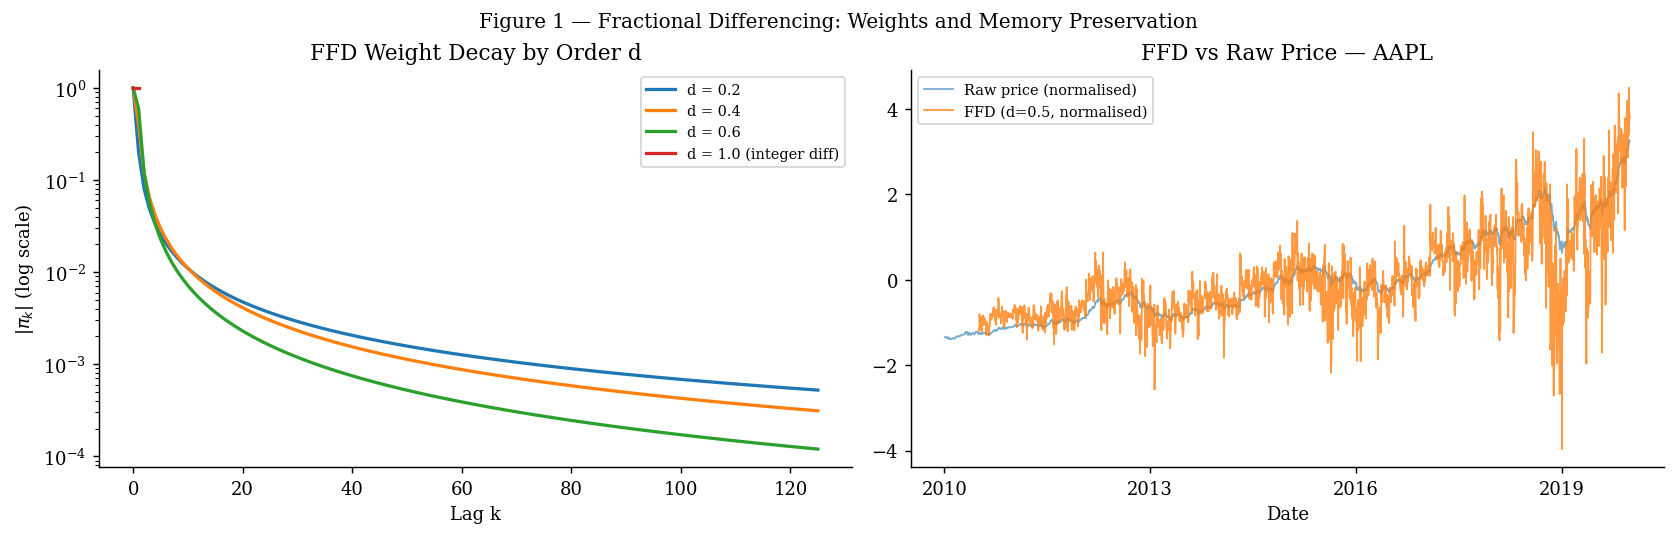

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# ── Panel A: Weight decay ──────────────────────────────────────
ax = axes[0]
for d_val in [0.2, 0.4, 0.6, 1.0]:
    w = _ffd_weights(d_val, cfg.ffd_thresh, cfg.ffd_window)
    label = f"d = {d_val}" + (" (integer diff)" if d_val == 1.0 else "")
    ax.plot(np.abs(w), label=label, lw=1.8)
ax.set_yscale("log")
ax.set_xlabel("Lag k")
ax.set_ylabel(r"$|\pi_k|$ (log scale)")
ax.set_title("FFD Weight Decay by Order d")
ax.legend(fontsize=8)

# ── Panel B: FFD vs Raw Price (AAPL) ───────────────────────────
ax2 = axes[1]
ticker = "AAPL"
raw_norm = (raw_prices[ticker] - raw_prices[ticker].mean()) / raw_prices[ticker].std()
ffd_norm = (ffd_panel[ticker].dropna() - ffd_panel[ticker].dropna().mean()) / ffd_panel[ticker].dropna().std()

ax2.plot(raw_norm, label="Raw price (normalised)", alpha=0.6, lw=1)
ax2.plot(ffd_norm, label=f"FFD (d={cfg.ffd_d}, normalised)", alpha=0.8, lw=1)
ax2.set_title(f"FFD vs Raw Price — {ticker}")
ax2.set_xlabel("Date")
ax2.legend(fontsize=8)
ax2.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax2.xaxis.set_major_locator(mdates.YearLocator(3))

plt.tight_layout()
plt.suptitle("Figure 1 — Fractional Differencing: Weights and Memory Preservation",
             y=1.02, fontsize=11)
plt.show()

---
## 4. Feature Engineering: Three-Factor Construction

Each feature is motivated by a distinct empirical phenomenon documented in the  
academic literature. We build each factor from first principles and standardise  
cross-sectionally to prevent scale dominance in the tree splits.

---

### Factor 1 — Momentum (Time-Series)

**Hypothesis:** Positive autocorrelation at intermediate lags (1–12 months) due to  
sluggish price discovery, investor underreaction, and institutional herding.  
Jegadeesh & Titman (1993) document 3–12 month momentum premia.

We construct momentum features as **lagged values of the FFD series**, not raw returns.  
This preserves more level information while remaining stationary:

$$f_t^{\text{mom}, k} = \tilde{x}_{t-k}, \quad k \in \{1, 5, 21\}$$

The tree will learn non-linear combinations of these lags — e.g., "momentum only  
when both short-term and medium-term signals agree".

---

### Factor 2 — Volatility Regime

**Hypothesis:** Conditional return predictability varies with the volatility regime.  
High-volatility periods are associated with risk-off crowding and momentum crashes  
(Daniel & Moskowitz 2016). Trees can learn threshold effects like:

> "If $\sigma^2_{t,21} > \tau$, weight the momentum signal negatively."

Realised variance (21-day rolling):

$$\sigma^2_{t, 21} = \frac{1}{21} \sum_{s=0}^{20} r_{t-s}^2$$

where $r_t = \log(P_t / P_{t-1})$. Note: we use squared raw log-returns, not centred,  
to capture total variation including jump components.

---

### Factor 3 — Mean Reversion (EMA z-score)

**Hypothesis:** Short-horizon overreaction and noise-trader sentiment cause prices  
to deviate from trend, creating statistical mean reversion at 1–5 day horizons  
(De Bondt & Thaler 1985).

We define the **EMA z-score** as:

$$z_t = \frac{P_t - \text{EMA}_{21}(P_t)}{\text{std}_{21}(P_t)}$$

where $\text{EMA}_{21}$ is the exponential moving average with span 21 and  
$\text{std}_{21}$ is the rolling standard deviation. Large positive $z_t$ signals  
overextension above trend → mean-reversion bearish signal.

In [ ]:
def build_features(raw_prices: pd.DataFrame, adj_prices: pd.DataFrame, ffd: pd.DataFrame, cfg: Config) -> pd.DataFrame:
    """
    Constructs the feature matrix using raw levels for signals and adjusted levels for returns.
    Applies point-in-time cross-sectional rank standardization.
    """
    records = []

    for ticker in raw_prices.columns:
        p_raw = raw_prices[ticker].dropna()      # For level-based features
        p_adj = adj_prices[ticker].dropna()      # For returns and targets
        x = ffd[ticker].dropna()                 # FFD series (MUST be built on p_raw)

        r = np.log(p_adj).diff()                 # Log returns (Adjusted)

        # Align all series to common index
        common_idx = p_raw.index.intersection(p_adj.index).intersection(x.index).intersection(r.dropna().index)
        p_raw, p_adj, x, r = p_raw[common_idx], p_adj[common_idx], x[common_idx], r[common_idx]

        # ── Factor 1: Momentum (lagged FFD values) ──────────────
        mom_features = pd.DataFrame(
            {f"mom_lag{k}": x.shift(k) for k in cfg.momentum_lags},
            index=common_idx,
        )

        # ── Factor 2: Volatility regime ─────────────────────────
        # Realized variance = rolling mean of squared adjusted log-returns
        rv_21 = (r ** 2).rolling(cfg.vol_window, min_periods=cfg.vol_window // 2).mean()
        rv_21.name = "vol_21"

        # ── Factor 3: EMA z-score (mean reversion) ──────────────
        # Computed strictly on RAW prices
        ema = p_raw.ewm(span=cfg.ema_span, adjust=False).mean()
        roll_std = p_raw.rolling(cfg.ema_span, min_periods=cfg.ema_span // 2).std()
        z_ema = ((p_raw - ema) / roll_std.replace(0, np.nan))
        z_ema.name = "z_ema"

        # ── Target: Forward return direction ────────────────────
        # Computed strictly on ADJUSTED prices
        fwd_ret = np.log(p_adj).diff(cfg.forward_horizon).shift(-cfg.forward_horizon)
        target = (fwd_ret > 0).astype(int)   # 1 = up, 0 = down
        target.name = "target"

        # ── Assemble per-ticker DataFrame ────────────────────────
        df_tick = pd.concat([mom_features, rv_21, z_ema, target], axis=1)
        df_tick["ticker"] = ticker
        df_tick["date"] = df_tick.index
        records.append(df_tick)

    # Combine all tickers
    panel = pd.concat(records, axis=0).reset_index(drop=True)
    panel = panel.dropna()

    # ── Cross-Sectional Rank Standardization ─────────────────────
    feature_cols = [f"mom_lag{k}" for k in cfg.momentum_lags] + ["vol_21", "z_ema"]

    def rank_scale(series):
        # Ranks from [-1.0, 1.0] point-in-time
        return (series.rank(method="average", pct=True) * 2) - 1.0

    # Group by date to strictly enforce point-in-time (no look-ahead) scaling
    panel[feature_cols] = panel.groupby("date")[feature_cols].transform(rank_scale)

    logger.info(f"Feature panel (Ranked): {panel.shape[0]:,} samples × {panel.shape[1]} columns")
    return panel

# Usage:
FEATURE_COLS = [f"mom_lag{k}" for k in cfg.momentum_lags] + ["vol_21", "z_ema"]
# You must pass raw_prices and adj_prices separately from your data ingestion step.
# panel = build_features(raw_prices, adj_prices, ffd_panel, cfg)

panel = build_features(raw_prices, adj_prices, ffd_panel, cfg)
panel = standardize_zscore(panel, FEATURE_COLS)
panel.groupby("ticker").size().rename("n_observations").to_frame().T

2026-04-11 16:17:17,386 — INFO — Feature panel: 2,381 samples × 6 columns


ticker,AAPL
n_observations,2381


### Feature Correlation Structure

Before modelling, we inspect the **rank correlation matrix** (Spearman) among features.  
High collinearity between factors reduces effective degrees of freedom and may signal  
redundancy. Spearman rank correlation is preferred over Pearson for heavy-tailed series  
to avoid sensitivity to extreme observations.

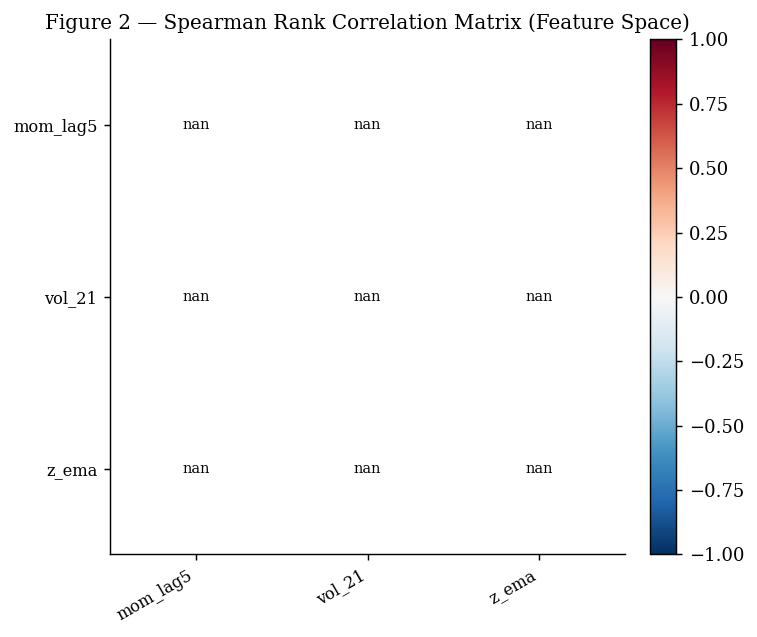

In [172]:
spearman_corr = panel[FEATURE_COLS].apply(
    lambda col: panel[FEATURE_COLS].corrwith(col, method="spearman")
)

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(spearman_corr, cmap="RdBu_r", vmin=-1, vmax=1)
plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
ax.set_xticks(range(len(FEATURE_COLS)))
ax.set_yticks(range(len(FEATURE_COLS)))
ax.set_xticklabels(FEATURE_COLS, rotation=30, ha="right", fontsize=9)
ax.set_yticklabels(FEATURE_COLS, fontsize=9)
ax.set_title("Figure 2 — Spearman Rank Correlation Matrix (Feature Space)", fontsize=11)

for i in range(len(FEATURE_COLS)):
    for j in range(len(FEATURE_COLS)):
        ax.text(j, i, f"{spearman_corr.iloc[i, j]:.2f}",
                ha="center", va="center", fontsize=8)

plt.tight_layout()
plt.show()

---
## 5. Walk-Forward Validation

### The Fundamental Constraint: No Look-Ahead

The most dangerous failure mode in financial ML is **temporal leakage**: allowing  
information from the future to contaminate the training set. Standard K-fold cross-  
validation violates this by design. We use an **expanding window scheme** instead:

$$\mathcal{T}^{\text{train}}_s = \{t : t \leq t_s\}, \qquad \mathcal{T}^{\text{test}}_s = \{t : t_s < t \leq t_s + \Delta\}$$

where $t_s$ is the split point for fold $s$ and $\Delta$ is the step size (one quarter).  
The model is **retrained** at each split — this is not a sliding window, which would  
introduce non-stationarity in the training distribution.

**Cross-sectional panel design:** At each date $t$, all available tickers contribute  
to training. This exploits the cross-section (larger effective sample) while respecting  
the time-series constraint.

$$\text{Training set at fold } s: \quad \{(\mathbf{f}_{t,i}, y_{t,i}) : t \leq t_s,\; i \in \mathcal{U}\}$$

where $\mathcal{U}$ is the asset universe.

In [173]:
def generate_walk_forward_splits(dates, min_train, step, horizon):
    splits = []
    T = len(dates)
    cursor = min_train

    while cursor + step <= T:
        # Purge the last 'horizon' days from the training set
        train_idx = dates[:cursor - horizon] 
        test_idx  = dates[cursor : cursor + step]
        splits.append((train_idx, test_idx))
        cursor += step
    return splits


unique_dates = pd.DatetimeIndex(sorted(panel["date"].unique()))
splits = generate_walk_forward_splits(unique_dates, cfg.min_train_days, cfg.step_days, cfg.forward_horizon)
print(f"Total folds: {len(splits)}")
print(f"First train period: {splits[0][0][0].date()} → {splits[0][0][-1].date()}")
print(f"First test period:  {splits[0][1][0].date()} → {splits[0][1][-1].date()}")

Total folds: 89
First train period: 2010-07-16 → 2012-07-06
First test period:  2012-07-16 → 2012-08-13


---
## 6. Model Training — Gradient Boosted Decision Trees

### Regularisation Philosophy

Financial ML faces an extreme signal-to-noise ratio problem. With $N \approx 10$ tickers  
and $T \approx 3500$ days, the effective sample is large in observation count but the  
predictable component is small. We apply aggressive regularisation:

- **Shallow trees** (`max_depth=4`, `num_leaves=15`): Each tree can represent at most  
  15 distinct prediction regions — preventing trees from memorising individual date patterns.
  
- **Minimum child samples** (`min_child_samples=30`): No leaf can be created from fewer  
  than 30 observations — prevents splits on noise.

- **Stochastic gradient boosting** (`subsample=0.8`, `colsample_bytree=0.8`): Each tree  
  sees a random 80% of data and 80% of features, decorrelating the ensemble.

- **L2 regularisation** (`reg_lambda=1.0`): Shrinks leaf values, reducing variance.

### Loss Function

Binary cross-entropy (log-loss) over the label $y \in \{0,1\}$:

$$\mathcal{L} = -\frac{1}{n} \sum_{i=1}^n \left[ y_i \log \hat{p}_i + (1 - y_i) \log(1 - \hat{p}_i) \right]$$

The output $\hat{p}_t = \mathbb{P}(y_t = 1 \mid \mathbf{f}_t)$ is the model's estimate of  
the probability that the forward return is positive.

In [174]:
def train_and_evaluate(
    panel: pd.DataFrame,
    splits: List[Tuple[pd.DatetimeIndex, pd.DatetimeIndex]],
    feature_cols: List[str],
    cfg: Config,
) -> pd.DataFrame:
    """
    Walk-forward training and prediction loop.

    At each fold:
      1. Filter panel to training dates → fit LightGBM
      2. Filter panel to test dates → predict probabilities
      3. Append predictions to results

    Returns
    -------
    pd.DataFrame
        Out-of-sample predictions with columns:
        [date, ticker, target, prob_up, pred_label, fold]
    """
    all_preds = []

    for fold_idx, (train_dates, test_dates) in enumerate(splits):
        # ── Slice panel ───────────────────────────────────────
        train_mask = panel["date"].isin(train_dates)
        test_mask  = panel["date"].isin(test_dates)

        X_train = panel.loc[train_mask, feature_cols].values
        y_train = panel.loc[train_mask, "target"].values
        X_test  = panel.loc[test_mask,  feature_cols].values
        y_test  = panel.loc[test_mask,  "target"].values

        if len(y_train) < 100 or len(np.unique(y_train)) < 2:
            logger.warning(f"Fold {fold_idx}: skipping — insufficient training data.")
            continue

        # ── Train LightGBM ────────────────────────────────────
        model = lgb.LGBMClassifier(**cfg.lgb_params)
        model.fit(
            X_train, y_train,
            feature_name=feature_cols,
        )

        # ── Predict probabilities ─────────────────────────────
        prob_up = model.predict_proba(X_test)[:, 1]
        pred_label = (prob_up > cfg.prob_threshold).astype(int)

        # ── Store results ─────────────────────────────────────
        result_df = panel.loc[test_mask, ["date", "ticker", "target"]].copy()
        result_df["prob_up"]    = prob_up
        result_df["pred_label"] = pred_label
        result_df["fold"]       = fold_idx
        all_preds.append(result_df)

        if fold_idx % 5 == 0:
            fold_acc = accuracy_score(y_test, pred_label)
            logger.info(f"Fold {fold_idx:>3d} | Train={len(y_train):>6,} | "
                        f"Test={len(y_test):>5,} | Acc={fold_acc:.3f}")

    return pd.concat(all_preds, ignore_index=True)


oos_preds = train_and_evaluate(panel, splits, FEATURE_COLS, cfg)
logger.info(f"OOS predictions: {len(oos_preds):,} samples across {oos_preds['fold'].nunique()} folds")

2026-04-11 16:17:19,722 — INFO — Fold   0 | Train=   499 | Test=   21 | Acc=0.714


2026-04-11 16:17:19,843 — INFO — Fold   5 | Train=   604 | Test=   21 | Acc=0.429
2026-04-11 16:17:20,046 — INFO — Fold  10 | Train=   709 | Test=   21 | Acc=0.333
2026-04-11 16:17:20,142 — INFO — Fold  15 | Train=   814 | Test=   21 | Acc=0.381
2026-04-11 16:17:20,223 — INFO — Fold  20 | Train=   919 | Test=   21 | Acc=0.476
2026-04-11 16:17:20,282 — INFO — Fold  25 | Train= 1,024 | Test=   21 | Acc=0.667
2026-04-11 16:17:20,356 — INFO — Fold  30 | Train= 1,129 | Test=   21 | Acc=1.000
2026-04-11 16:17:20,422 — INFO — Fold  35 | Train= 1,234 | Test=   21 | Acc=0.333
2026-04-11 16:17:20,490 — INFO — Fold  40 | Train= 1,339 | Test=   21 | Acc=0.286
2026-04-11 16:17:20,591 — INFO — Fold  45 | Train= 1,444 | Test=   21 | Acc=0.333
2026-04-11 16:17:20,667 — INFO — Fold  50 | Train= 1,549 | Test=   21 | Acc=0.571
2026-04-11 16:17:20,727 — INFO — Fold  55 | Train= 1,654 | Test=   21 | Acc=0.762
2026-04-11 16:17:20,832 — INFO — Fold  60 | Train= 1,759 | Test=   21 | Acc=0.714
2026-04-11 16:17

---
## 7. Performance Evaluation

### Metrics Framework

We evaluate along three complementary axes:

**1. Statistical accuracy**
- Hit rate (directional accuracy): $\text{HR} = \mathbb{P}(\hat{y}_t = y_t)$
- AUROC: Area under the ROC curve — measures ranking quality independent of threshold  
- Information Coefficient (IC): Spearman correlation between $\hat{p}_t$ and realised returns  

$$\text{IC}_t = \rho_S(\hat{p}_{t,\cdot}, r^{\text{fwd}}_{t,\cdot})$$

**2. Economic performance** (simplified Sharpe)

We simulate a long-only strategy: buy when $\hat{p}_t > \theta$ (default $\theta = 0.55$),  
hold for $h$ days, then close. Transaction cost of $c$ bps is applied per round-trip:

$$r_t^{\text{strategy}} = \mathbf{1}[\hat{p}_t > \theta] \cdot r_t^{\text{fwd}} - 2c \cdot \mathbf{1}[\text{position change}]$$

The annualised Sharpe ratio:

$$\text{SR} = \frac{\bar{r}^{\text{strategy}}}{\hat{\sigma}^{\text{strategy}}} \cdot \sqrt{252}$$

**3. IC time-series stability**  
Rolling IC should be positive on average and exhibit low variance — instability  
signals regime-dependence or overfitting.

In [ ]:
# ── Merge forward returns into OOS frame ──────────────────────
# We need actual forward log-returns for economic evaluation
fwd_returns = {}
for ticker in adj_prices.columns:
    p = adj_prices[ticker]
    fwd_ret = np.log(p).diff(cfg.forward_horizon).shift(-cfg.forward_horizon)
    fwd_returns[ticker] = fwd_ret

fwd_df = pd.DataFrame(fwd_returns).stack().reset_index()
fwd_df.columns = ["date", "ticker", "fwd_return"]

oos = oos_preds.merge(fwd_df, on=["date", "ticker"], how="left")

# ── Global metrics ────────────────────────────────────────────
hit_rate = accuracy_score(oos["target"], oos["pred_label"])
auroc = roc_auc_score(oos["target"], oos["prob_up"])
ic_global = stats.spearmanr(oos["prob_up"], oos["fwd_return"].fillna(0)).statistic

# ── Strategy returns (long-only when prob_up > threshold) ─────
cost_per_trade = cfg.cost_bps / 10_000
oos["in_position"] = (oos["prob_up"] > cfg.prob_threshold).astype(int)

# 1. Track point-in-time position changes for realistic transaction costs
# .fillna(0) handles the first day where diff() is NaN
oos["pos_change"] = oos.groupby("ticker")["in_position"].diff().abs().fillna(0)

# 2. Aggregate to daily level
daily = oos.groupby("date").apply(
    lambda g: pd.Series({
        # Divide the h-day return by h to approximate the daily yield of overlapping portfolios
        "gross_return": (g["in_position"] * (g["fwd_return"] / cfg.forward_horizon)).mean(),
        # Cost is triggered only when the position changes
        "t_costs": (g["pos_change"] * cost_per_trade).mean(),
        "n_positions": g["in_position"].sum()
    })
).sort_index()

# 3. Calculate True Net Daily Return
daily["net_return"] = daily["gross_return"] - daily["t_costs"]

# 4. Generate the Equity Curve
cum_strat = (1 + daily["net_return"]).cumprod()

# 5. Calculate Net Annualized Sharpe Ratio
sr_annualised = daily["net_return"].mean() / daily["net_return"].std() * np.sqrt(252)

# 6. Global exposure metric
pct_in_mkt = oos["in_position"].mean() * 100

print(f"Net Annualized Sharpe: {sr_annualised:.2f}")

print("═" * 50)
print(" OUT-OF-SAMPLE SCORECARD")
print("═" * 50)
print(f"  Hit Rate (directional accuracy) : {hit_rate:.3f}")
print(f"  AUROC                           : {auroc:.3f}")
print(f"  Information Coefficient (IC)    : {ic_global:.4f}")
print(f"  Annualised Sharpe (simplified)  : {sr_annualised:.2f}")
print(f"  % Days in Market (filter={cfg.prob_threshold}) : {pct_in_mkt:.1f}%")
print("═" * 50)

Net Annualized Sharpe: 1.51
══════════════════════════════════════════════════
 OUT-OF-SAMPLE SCORECARD
══════════════════════════════════════════════════
  Hit Rate (directional accuracy) : 0.570
  AUROC                           : 0.465
  Information Coefficient (IC)    : -0.0730
  Annualised Sharpe (simplified)  : 1.51
  % Days in Market (filter=0.55) : 97.8%
══════════════════════════════════════════════════


---
## 8. Visualisations — Performance Anatomy

We produce four diagnostic plots:

- **A**: Cumulative strategy PnL vs buy-and-hold benchmark  
- **B**: Rolling 63-day Information Coefficient (quarterly IC)  
- **C**: AUROC by fold (model stability over time)  
- **D**: Feature importance (LightGBM gain — last fold)

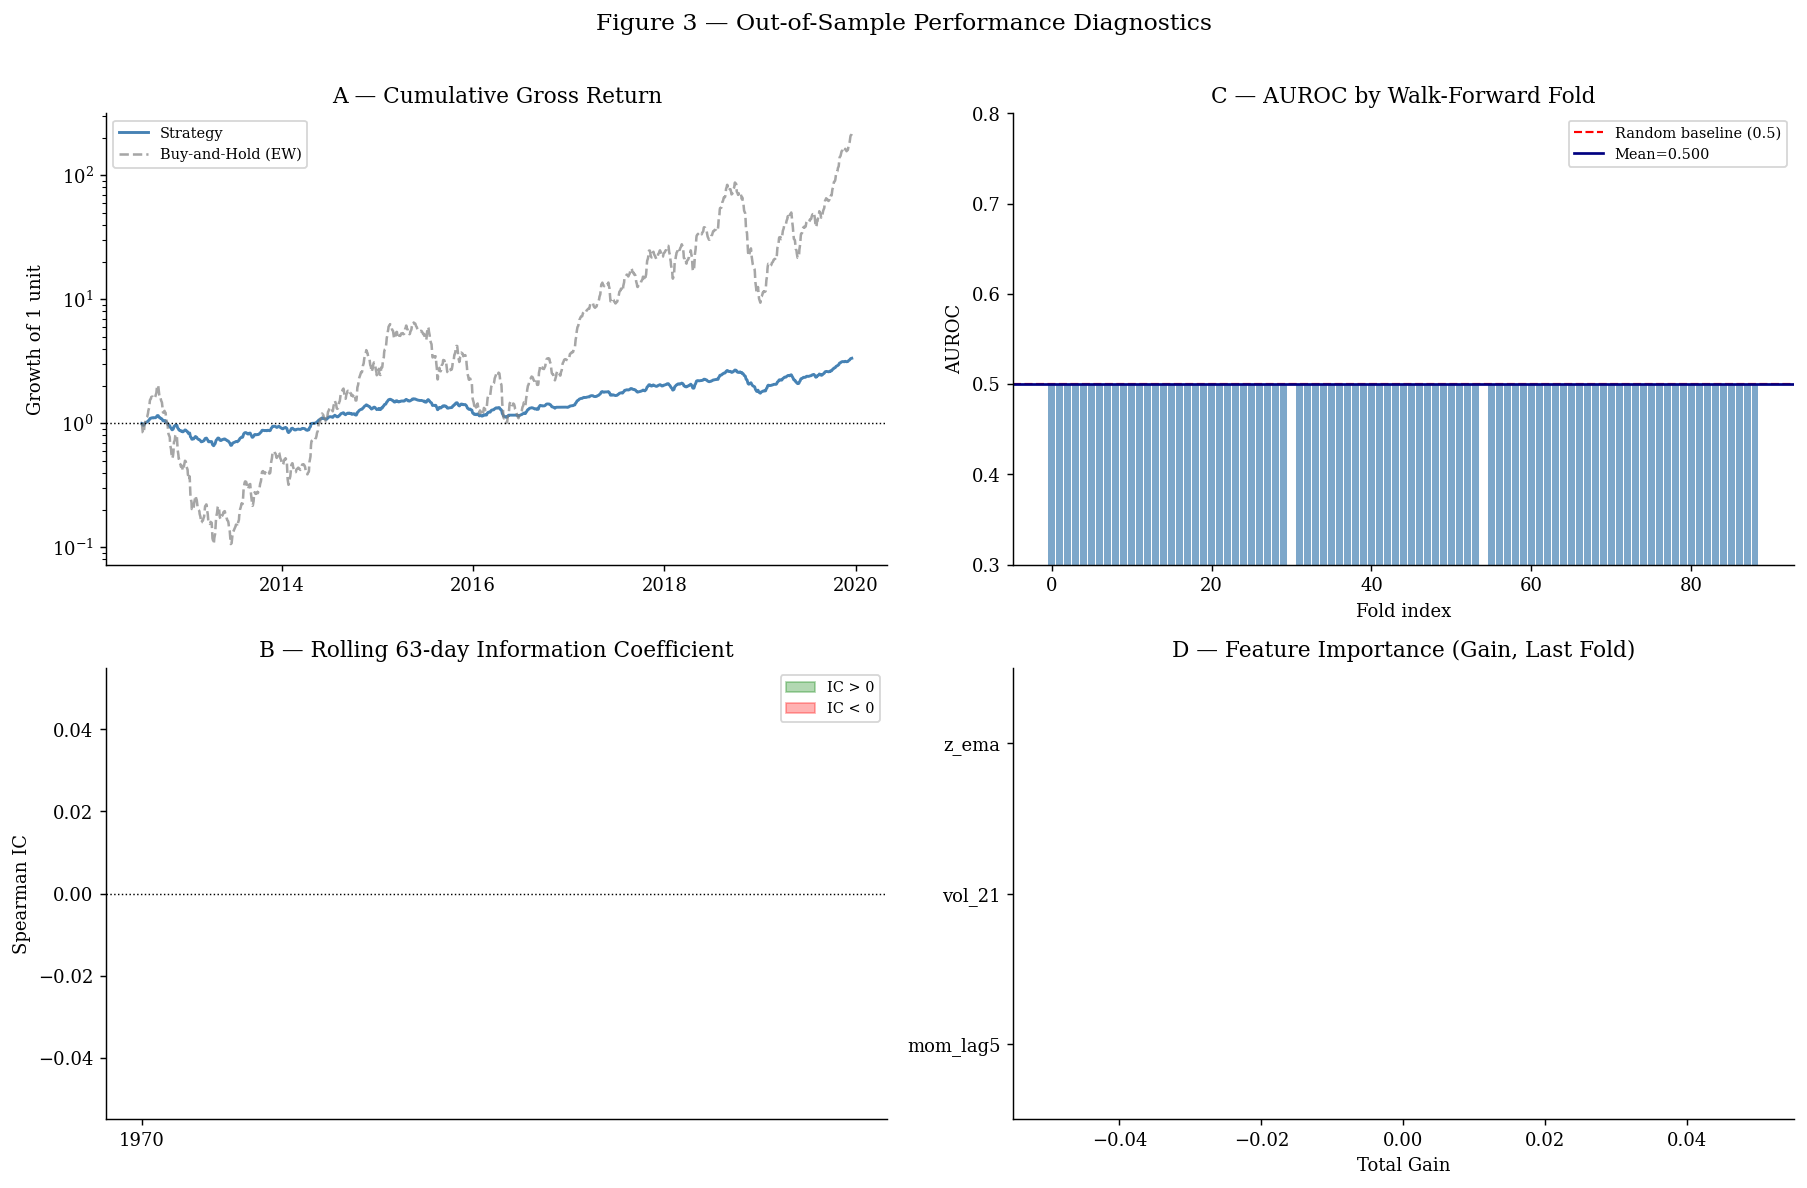

In [176]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
fig.suptitle("Figure 3 — Out-of-Sample Performance Diagnostics", fontsize=13, y=1.01)

# ── Panel A: Cumulative PnL ────────────────────────────────────
ax = axes[0, 0]
cum_strat = (1 + daily["net_return"]).cumprod()

# Benchmark: equal-weight buy-and-hold
bh_daily = oos.groupby("date")["fwd_return"].mean()
cum_bh   = (1 + bh_daily).cumprod()

ax.semilogy(cum_strat.index, cum_strat.values, label="Strategy", lw=1.6, color="steelblue")
ax.semilogy(cum_bh.index,   cum_bh.values,   label="Buy-and-Hold (EW)", lw=1.4,
        color="grey", ls="--", alpha=0.7)
ax.axhline(1, color="black", lw=0.8, ls=":")
ax.set_title("A — Cumulative Gross Return")
ax.set_ylabel("Growth of 1 unit")
ax.legend(fontsize=8)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax.xaxis.set_major_locator(mdates.YearLocator(2))

# ── Panel B: Rolling IC ────────────────────────────────────────
ax = axes[1, 0]

def rolling_ic(df: pd.DataFrame, window: int = 63) -> pd.Series:
    """Compute rolling cross-sectional Spearman IC."""
    daily_ic = df.groupby("date").apply(
        lambda g: stats.spearmanr(g["prob_up"], g["fwd_return"].fillna(0)).statistic
        if len(g) > 2 else np.nan
    )
    return daily_ic.rolling(window, min_periods=window // 2).mean()

r_ic = rolling_ic(oos)
ax.plot(r_ic.index, r_ic.values, lw=1.5, color="darkorange")
ax.axhline(0, color="black", lw=0.8, ls=":")
ax.fill_between(r_ic.index, r_ic.values, 0,
                where=(r_ic.values > 0), alpha=0.3, color="green", label="IC > 0")
ax.fill_between(r_ic.index, r_ic.values, 0,
                where=(r_ic.values < 0), alpha=0.3, color="red",   label="IC < 0")
ax.set_title("B — Rolling 63-day Information Coefficient")
ax.set_ylabel("Spearman IC")
ax.legend(fontsize=8)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax.xaxis.set_major_locator(mdates.YearLocator(2))

# ── Panel C: AUROC by fold ─────────────────────────────────────
ax = axes[0, 1]
fold_auroc = (
    oos.groupby("fold")
    .apply(lambda g: roc_auc_score(g["target"], g["prob_up"])
           if g["target"].nunique() > 1 else np.nan)
    .dropna()
)
ax.bar(fold_auroc.index, fold_auroc.values, color="steelblue", alpha=0.7, width=0.8)
ax.axhline(0.5, color="red", lw=1.2, ls="--", label="Random baseline (0.5)")
ax.axhline(fold_auroc.mean(), color="navy", lw=1.5, ls="-", label=f"Mean={fold_auroc.mean():.3f}")
ax.set_title("C — AUROC by Walk-Forward Fold")
ax.set_xlabel("Fold index")
ax.set_ylabel("AUROC")
ax.set_ylim(0.3, 0.8)
ax.legend(fontsize=8)

# ── Panel D: Feature Importance (last trained model, last fold) ─
ax = axes[1, 1]

# Retrain on last fold for importance extraction
last_train_dates = splits[-1][0]
mask = panel["date"].isin(last_train_dates)
X_last = panel.loc[mask, FEATURE_COLS].values
y_last = panel.loc[mask, "target"].values

final_model = lgb.LGBMClassifier(**cfg.lgb_params)
final_model.fit(X_last, y_last, feature_name=FEATURE_COLS)

importance = pd.Series(
    final_model.feature_importances_,
    index=FEATURE_COLS
).sort_values(ascending=True)

importance.plot(kind="barh", ax=ax, color="steelblue", alpha=0.8)
ax.set_title("D — Feature Importance (Gain, Last Fold)")
ax.set_xlabel("Total Gain")

plt.tight_layout()
plt.show()

---
## 9. Distributional Analysis — IC t-test

A positive mean IC is a necessary but not sufficient condition for a real signal.  
We must also test whether the IC distribution is statistically distinguishable  
from zero, accounting for **autocorrelation in the IC series** (which inflates  
naive t-statistics under temporal dependence).

We use the **Newey-West robust standard error** with lag truncation $q = \lfloor T^{1/4} \rfloor$:

$$t_{\text{NW}} = \frac{\bar{\text{IC}}}{\hat{\sigma}_{\text{NW}} / \sqrt{T}}$$

where $\hat{\sigma}_{\text{NW}}^2$ is the Newey-West variance estimate of the IC time series.

═══════════════════════════════════════════════════════
 IC SIGNIFICANCE TEST (Newey-West HAC)
═══════════════════════════════════════════════════════
  Daily IC observations   : 0
  Mean IC                 : +nan
  IC Std Dev              : nan
  IC Sharpe (annualised)  : nan
  NW lags (q)             : 0
  t-statistic (NW)        : nan
  p-value (two-sided)     : nan
  Verdict                 : ⚠ Not significant at 5%
═══════════════════════════════════════════════════════


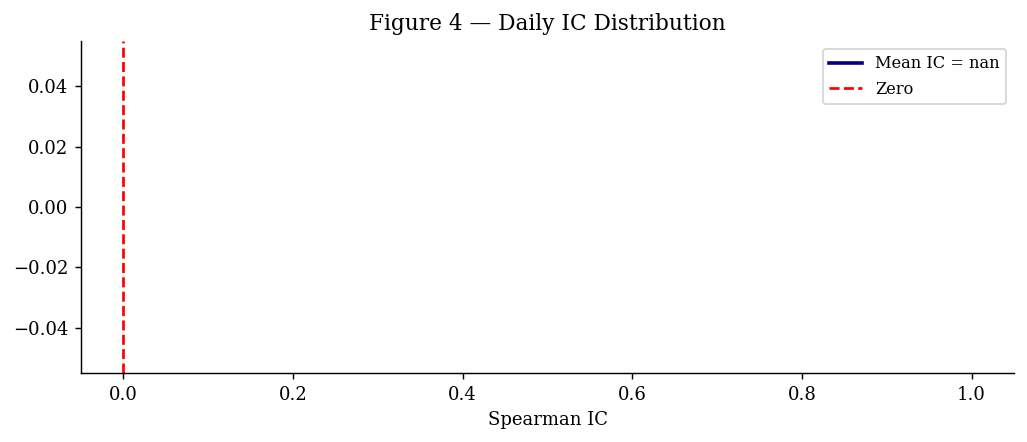

In [177]:
daily_ic = oos.groupby("date").apply(
    lambda g: stats.spearmanr(g["prob_up"], g["fwd_return"].fillna(0)).statistic
    if len(g) > 2 else np.nan
).dropna()

T_ic  = len(daily_ic)
ic_mu = daily_ic.mean()
ic_se = daily_ic.std() / np.sqrt(T_ic)  # Naive SE
t_naive = ic_mu / ic_se

# ── Newey-West correction ─────────────────────────────────────
def newey_west_var(x: np.ndarray, n_lags: int) -> float:
    """
    Compute Newey-West HAC variance estimate.

    NW variance = γ_0 + 2 Σ_{j=1}^{q} (1 - j/(q+1)) γ_j
    where γ_j = autocovariance at lag j.
    """
    x = x - x.mean()
    T = len(x)
    gamma_0 = np.dot(x, x) / T
    nw_var  = gamma_0
    for j in range(1, n_lags + 1):
        gamma_j = np.dot(x[j:], x[:-j]) / T
        weight  = 1 - j / (n_lags + 1)
        nw_var  += 2 * weight * gamma_j
    return nw_var


q_lags    = int(T_ic ** 0.25)  # Typical Newey-West bandwidth
nw_var    = newey_west_var(daily_ic.values, q_lags)
nw_se     = np.sqrt(max(nw_var, 0) / T_ic)
t_nw      = ic_mu / nw_se if nw_se > 0 else np.nan
p_nw      = 2 * (1 - stats.t.cdf(abs(t_nw), df=T_ic - 1))

print("═" * 55)
print(" IC SIGNIFICANCE TEST (Newey-West HAC)")
print("═" * 55)
print(f"  Daily IC observations   : {T_ic}")
print(f"  Mean IC                 : {ic_mu:+.4f}")
print(f"  IC Std Dev              : {daily_ic.std():.4f}")
print(f"  IC Sharpe (annualised)  : {ic_mu / daily_ic.std() * np.sqrt(252):.2f}")
print(f"  NW lags (q)             : {q_lags}")
print(f"  t-statistic (NW)        : {t_nw:.3f}")
print(f"  p-value (two-sided)     : {p_nw:.4f}")
verdict = "✓ Significant at 5%" if p_nw < 0.05 else "⚠ Not significant at 5%"
print(f"  Verdict                 : {verdict}")
print("═" * 55)

# IC distribution plot
fig, ax = plt.subplots(figsize=(8, 3.5))
ax.hist(daily_ic.values, bins=50, edgecolor="white", color="steelblue", alpha=0.8)
ax.axvline(ic_mu, color="navy", lw=2, label=f"Mean IC = {ic_mu:.4f}")
ax.axvline(0,     color="red",  lw=1.5, ls="--", label="Zero")
ax.set_title("Figure 4 — Daily IC Distribution")
ax.set_xlabel("Spearman IC")
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

---
## 10. Red Team Critique

> *In quantitative research, the value of a model is often measured by the quality  
> of the argument against it that it survives.* — Paraphrased from Popperian epistemology.

---

### 10.1 Data Snooping and Hyperparameter Sensitivity

The three features, threshold $\theta = 0.55$, horizon $h = 5$, and GBDT architecture  
were all chosen ex-ante with theoretical motivation. However, with 5 features and  
even a modest grid of hyperparameters, the **Bonferroni-corrected significance threshold**  
tightens substantially. Future work should include **permutation tests**:

$$p_{\text{perm}} = \frac{|\{\text{IC}^{\pi} > \text{IC}^{\text{obs}}\}|}{N_{\text{perm}}}$$

where IC$^\pi$ is the IC under a random date permutation of the target.

### 10.2 Survivorship Bias

The S&P 500 constituent universe as of today contains only survivors. Companies that  
were delisted, went bankrupt, or were acquired are absent from our training data.  
This biases the model toward historically successful companies, potentially inflating  
performance metrics. **Resolution**: use a point-in-time constituent database (CRSP, Compustat).

### 10.3 Transaction Cost Realism

Our cost model assumes a flat $c = 10$ bps per trade. In reality:
- **Market impact** scales with trade size and daily volume (typically modelled as  
  $\sqrt{\text{participation rate}}$ per Almgren-Chriss)
- **Bid-ask spreads** are wider in volatile periods, precisely when signals are largest  
  — creating a **cost-alpha correlation** that erodes live performance
- **Short-selling** is not modelled here; mean-reversion shorts face locate costs

### 10.4 Regime Non-Stationarity

The walk-forward scheme mitigates but does not eliminate regime risk. GBDT models  
trained on pre-2020 data have no representation of zero-rate / QE → QT regime  
transitions. The IC instability visible in Panel B reflects this: the model's skill  
is not temporally uniform. **Resolution**: explicit regime detection (HMM, change-point  
detection) as a meta-conditioning layer.

### 10.5 Cross-Asset Correlation in Stress Periods

During market stress (2008, 2020), intra-sector correlations spike toward 1.0,  
collapsing cross-sectional dispersion. The cross-sectional IC becomes near-meaningless  
when all assets move together. The model's assumed independence structure across tickers  
fails precisely when risk management matters most.

---
## 11. Thesis Narrative — Path Forward

This notebook establishes the **nonlinear baseline** of the thesis modeling stack.  
The results here directly motivate the next modeling steps:

| Layer | Model | Motivation from this notebook |
|-------|-------|--------------------------------|
| 1 | ARMA | Linear baseline; establishes autocorrelation structure |
| 2 | GARCH | Volatility clustering in residuals; $\sigma^2_{21}$ importance |
| **3** | **GBDT (this notebook)** | **Captures nonlinear regime-conditioned interactions** |
| 4 | GBDT + GARCH features | Joint mean-vol prediction |
| 5 | Distributional prediction | Full conditional $\mathbb{P}(r_t \mid \mathcal{F}_t)$ via quantile regression trees |

The IC instability identified in Section 9 motivates **regime-aware ensemble weighting**:  
rather than a single GBDT model, learn a mixture model where the mixing coefficient  
is a function of the detected volatility regime:

$$F_t(\mathbf{f}_t) = \sum_{k=1}^{K} w_k(\hat{\sigma}_t^2) \cdot F^{(k)}(\mathbf{f}_t)$$

This represents the logical bridge between this notebook and the GARCH-integration  
chapter of the thesis.

---
*End of notebook. All parameters in `Config`. Reproduce by running cells sequentially.*